# Compare Existing and Reproduced DUALFloodGNN Results

This notebook compares the existing `DUALFloodGNN` results and the reproduced `DUALFloodGNN_2026-08-26_03-07-26` results against the existing run ID 39 baselines.

- **Node volume:** existing DUALFloodGNN, reproduced DUALFloodGNN, GINE, and HydroGraphNet
- **Edge flow:** existing DUALFloodGNN, reproduced DUALFloodGNN, and EdgeGraphSAGE
- **Depth baselines:** not included in direct metric tables because they are water-depth predictions, while DUALFloodGNN stores water volume. Use `view_results.ipynb`'s depth-conversion workflow for that comparison.

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS_DIR = Path('results')
RUN_ID = 39

MODEL_RESULTS = {
    'DUALFloodGNN (existing)': RESULTS_DIR / f'DUALFloodGNN_runid_{RUN_ID}_metrics.npz',
    'DUALFloodGNN (reproduced)': Path(f'saved_metrics/DUALFloodGNN_2026-08-26_03-07-26_runid_{RUN_ID}_test_metrics.npz'),
    'GINE': RESULTS_DIR / 'volume_baselines' / f'GINE_runid_{RUN_ID}_metrics.npz',
    'HydroGraphNet': RESULTS_DIR / 'volume_baselines' / f'HydroGraphNet_runid_{RUN_ID}_metrics_vol.npz',
    'EdgeGraphSAGE': RESULTS_DIR / 'flow_baselines' / f'EdgeGraphSAGE_runid_{RUN_ID}_metrics.npz',
}

for label, path in MODEL_RESULTS.items():
    if not path.exists():
        raise FileNotFoundError(f'{label} result file not found: {path}')

results = {label: np.load(path, allow_pickle=True) for label, path in MODEL_RESULTS.items()}

for label, data in results.items():
    print(f'{label}: {MODEL_RESULTS[label]}')
    print(f'  keys: {data.files}')

DUALFloodGNN (existing): results\DUALFloodGNN_runid_39_metrics.npz
  keys: ['timestamps', 'pred', 'target', 'edge_pred', 'edge_target', 'rmse', 'rmse_flooded', 'mae', 'mae_flooded', 'nse', 'nse_flooded', 'csi', 'edge_rmse', 'edge_rmse_flooded', 'edge_mae', 'edge_mae_flooded', 'edge_nse', 'edge_nse_flooded', 'global_mass_loss', 'local_mass_loss', 'inference_time']
DUALFloodGNN (reproduced): saved_metrics\DUALFloodGNN_2026-08-26_03-07-26_runid_39_test_metrics.npz
  keys: ['timestamps', 'pred', 'target', 'edge_pred', 'edge_target', 'rmse', 'mae', 'nse', 'csi', 'rmse_flooded', 'mae_flooded', 'nse_flooded', 'edge_rmse', 'edge_mae', 'edge_nse', 'global_mass_loss', 'local_mass_loss', 'total_time', 'inference_time']
GINE: results\volume_baselines\GINE_runid_39_metrics.npz
  keys: ['timestamps', 'pred', 'target', 'edge_pred', 'edge_target', 'rmse', 'rmse_flooded', 'mae', 'mae_flooded', 'nse', 'nse_flooded', 'csi', 'edge_rmse', 'edge_rmse_flooded', 'edge_mae', 'edge_mae_flooded', 'edge_nse', 'ed

## Summary metrics

The tables below average each per-timestep metric over run ID 39. Lower is better for RMSE, MAE, and mass-loss error; higher is better for NSE and CSI.

In [15]:
def mean_metric(data, key):
    if key not in data or data[key].size == 0:
        return np.nan
    return float(np.asarray(data[key]).mean())

volume_labels = ['DUALFloodGNN (existing)', 'DUALFloodGNN (reproduced)', 'GINE', 'HydroGraphNet']
volume_metrics = ['rmse', 'mae', 'nse', 'csi', 'global_mass_loss', 'local_mass_loss']
volume_summary = pd.DataFrame(
    {
        label: {metric: mean_metric(results[label], metric) for metric in volume_metrics}
        for label in volume_labels
    }
).T

edge_labels = ['DUALFloodGNN (existing)', 'DUALFloodGNN (reproduced)', 'EdgeGraphSAGE']
edge_metrics = ['edge_rmse', 'edge_mae', 'edge_nse']
edge_summary = pd.DataFrame(
    {
        label: {metric: mean_metric(results[label], metric) for metric in edge_metrics}
        for label in edge_labels
    }
).T

print('Node volume comparison')
display(volume_summary.style.format('{:.6g}'))
print('Edge flow comparison')
display(edge_summary.style.format('{:.6g}'))

Node volume comparison


,rmse,mae,nse,csi,global_mass_loss,local_mass_loss
DUALFloodGNN (existing),2297.73,1074.37,0.978969,0.831275,453.207,-71915
DUALFloodGNN (reproduced),3001.01,1355.86,0.961031,0.812251,544.425,33581.2
GINE,4386.33,2153.46,0.890755,0.688349,925.432,71.0359
HydroGraphNet,7621.18,3847.23,0.587431,0.631693,-370602,nan


Edge flow comparison


,edge_rmse,edge_mae,edge_nse
DUALFloodGNN (existing),24.7719,10.8907,0.987884
DUALFloodGNN (reproduced),31.0536,13.1788,0.978267
EdgeGraphSAGE,49.0029,17.9239,0.920425


## Metric curves

These plots show how performance changes over the rollout. The node curves compare water-volume predictions; the edge curves compare face-flow predictions.

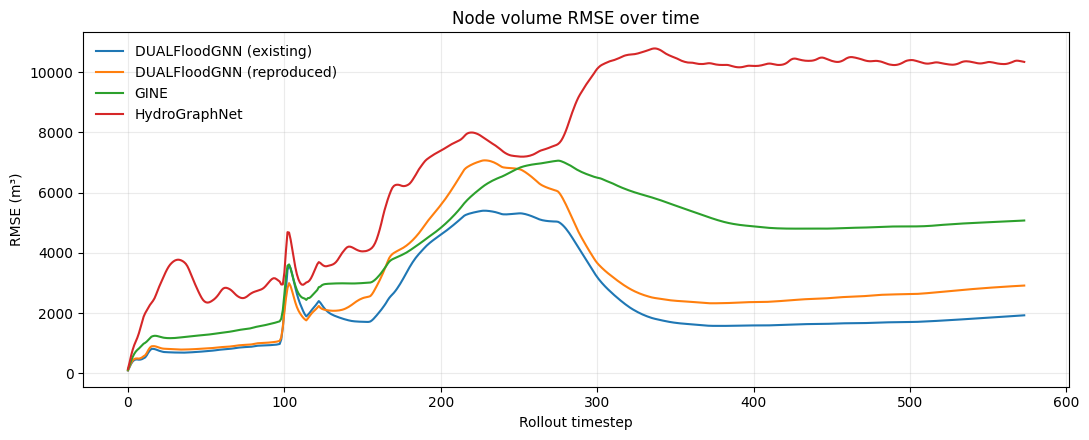

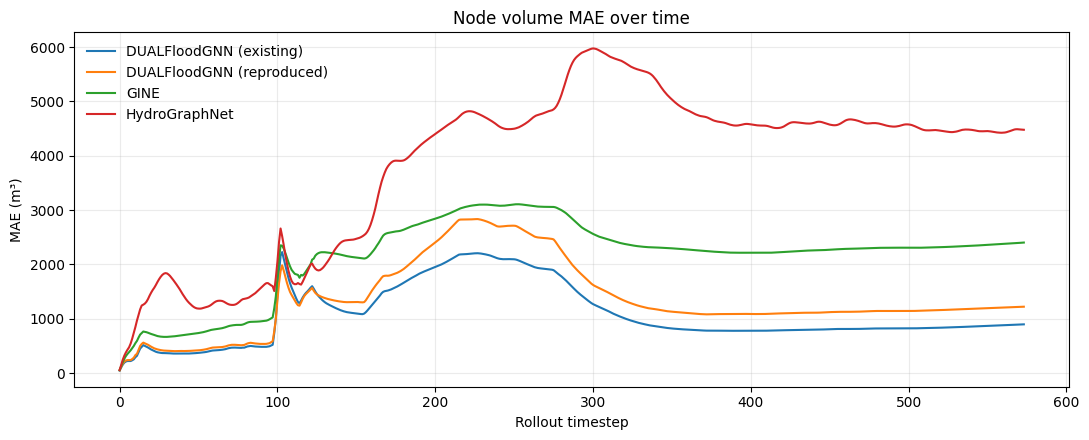

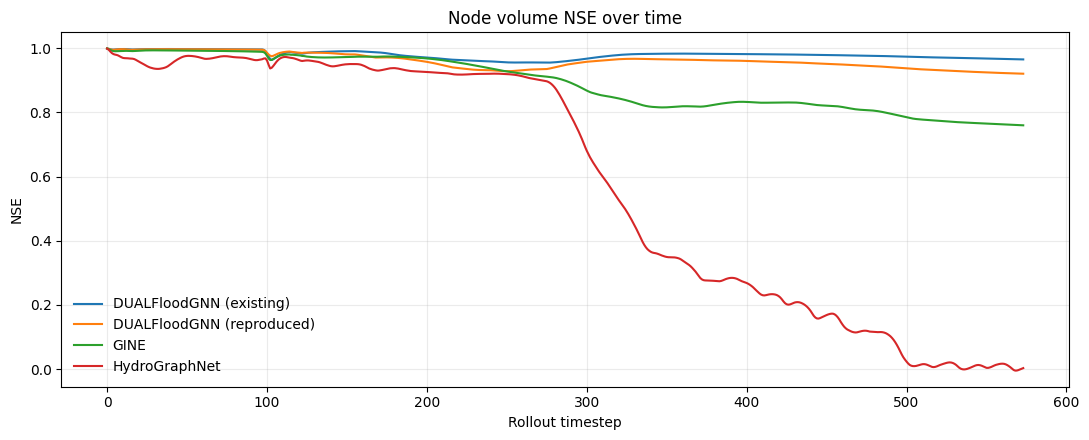

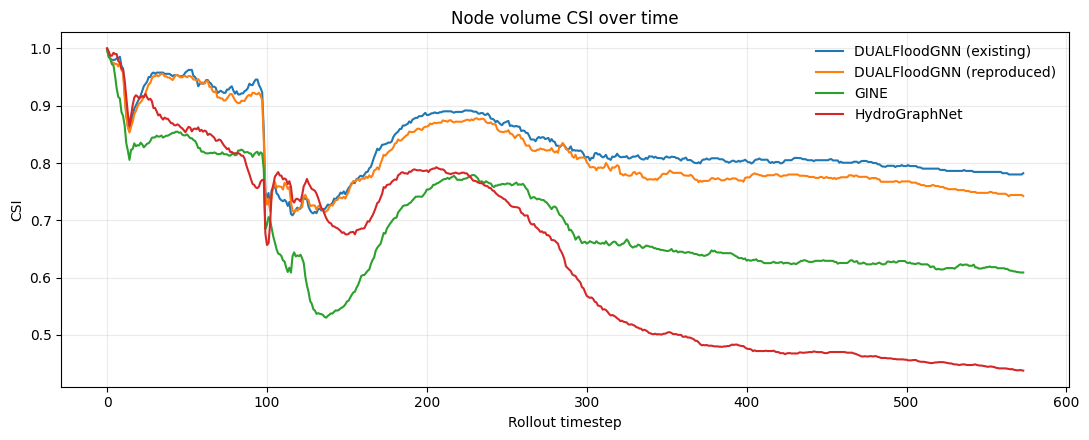

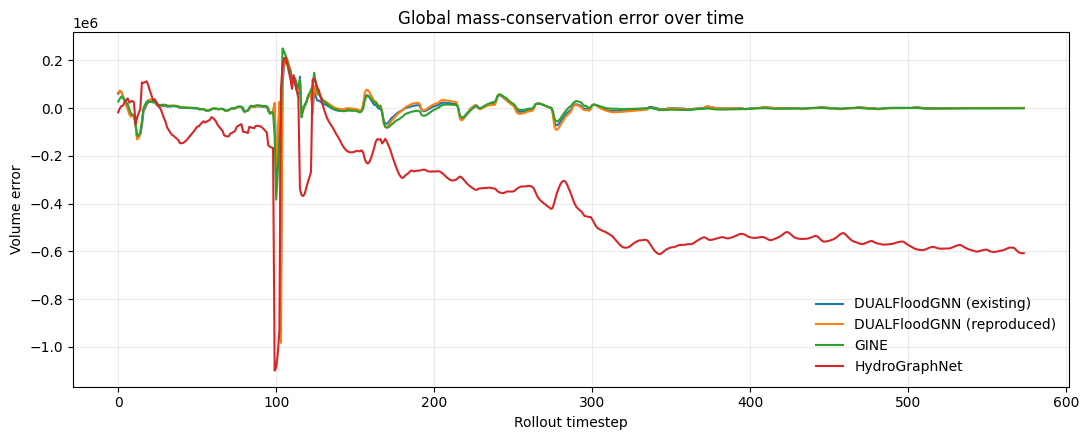

Skipping HydroGraphNet: metric 'local_mass_loss' is not present.


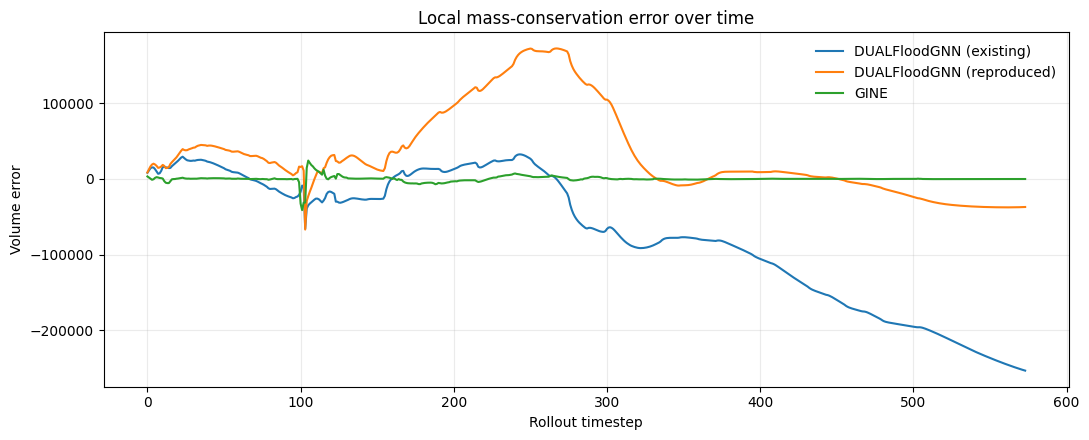

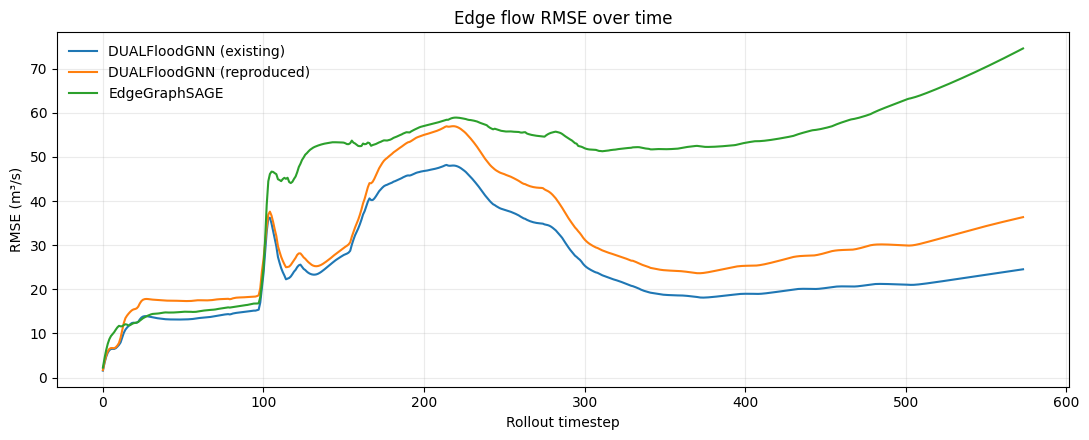

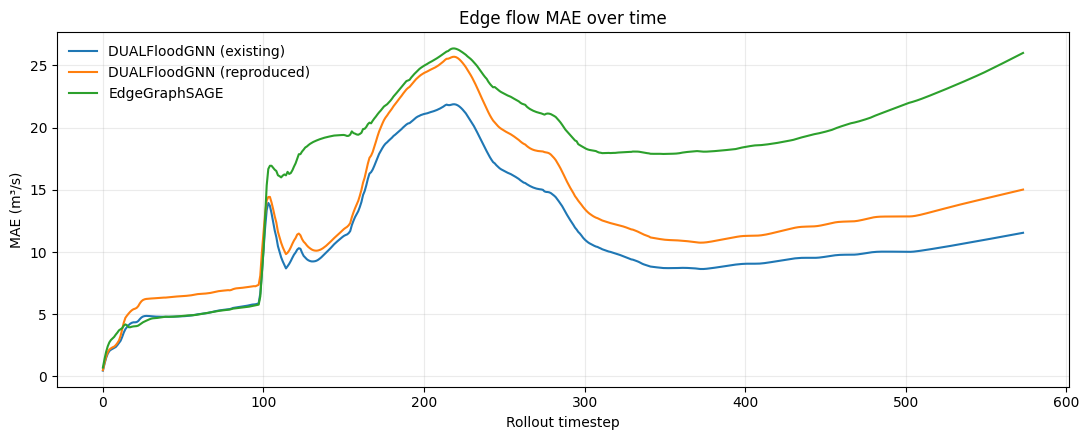

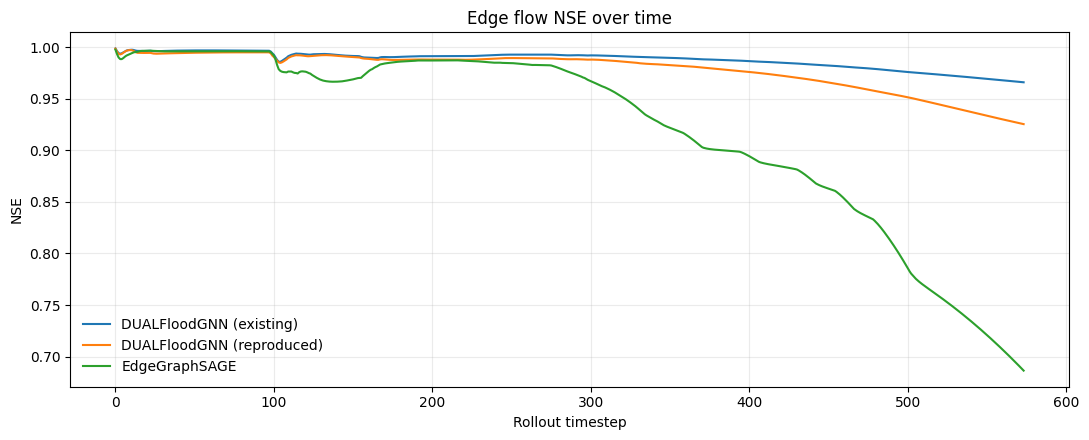

In [8]:
def plot_metric_curves(labels, metric, title, ylabel):
    plt.figure(figsize=(11, 4.5))
    plotted = False
    for label in labels:
        data = results[label]
        if metric not in data:
            print(f"Skipping {label}: metric '{metric}' is not present.")
            continue
        values = np.asarray(data[metric]).squeeze()
        if values.size == 0:
            print(f"Skipping {label}: metric '{metric}' is empty.")
            continue
        plt.plot(values, label=label, linewidth=1.5)
        plotted = True
    if not plotted:
        plt.close()
        return
    plt.title(title)
    plt.xlabel('Rollout timestep')
    plt.ylabel(ylabel)
    plt.grid(alpha=0.25)
    plt.legend(framealpha=0)
    plt.tight_layout()
    plt.show()

for metric, title, ylabel in [
    ('rmse', 'Node volume RMSE over time', 'RMSE (m³)'),
    ('mae', 'Node volume MAE over time', 'MAE (m³)'),
    ('nse', 'Node volume NSE over time', 'NSE'),
    ('csi', 'Node volume CSI over time', 'CSI'),
    ('global_mass_loss', 'Global mass-conservation error over time', 'Volume error'),
    ('local_mass_loss', 'Local mass-conservation error over time', 'Volume error'),
]:
    plot_metric_curves(volume_labels, metric, title, ylabel)

for metric, title, ylabel in [
    ('edge_rmse', 'Edge flow RMSE over time', 'RMSE (m³/s)'),
    ('edge_mae', 'Edge flow MAE over time', 'MAE (m³/s)'),
    ('edge_nse', 'Edge flow NSE over time', 'NSE'),
]:
    plot_metric_curves(edge_labels, metric, title, ylabel)

## Total predicted water volume

This plot compares the total predicted water volume against the shared ground truth. It is a useful rollout-level check because errors can accumulate even when average per-cell metrics look reasonable.

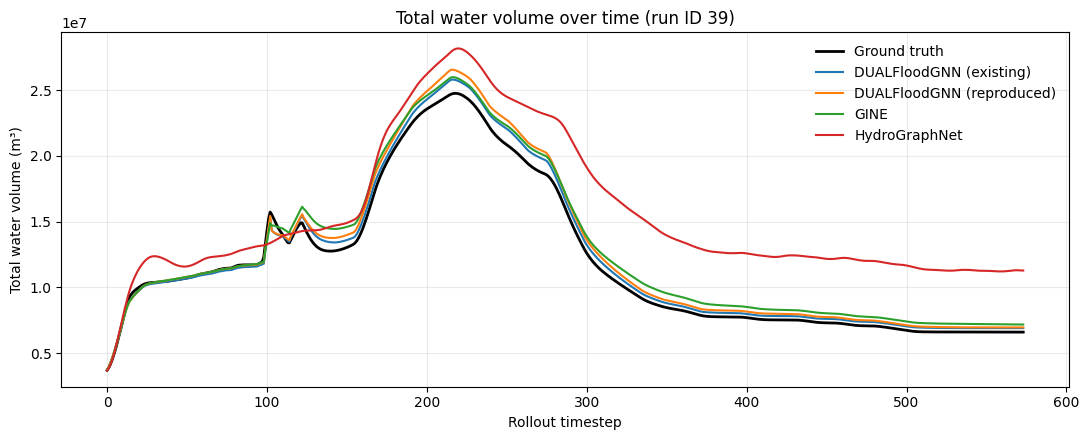

In [9]:
ground_truth = np.asarray(results['DUALFloodGNN (reproduced)']['target']).squeeze(-1)

plt.figure(figsize=(11, 4.5))
plt.plot(ground_truth.sum(axis=1), label='Ground truth', color='black', linewidth=2)
for label in volume_labels:
    prediction = np.asarray(results[label]['pred']).squeeze(-1)
    plt.plot(prediction.sum(axis=1), label=label, linewidth=1.5)

plt.title(f'Total water volume over time (run ID {RUN_ID})')
plt.xlabel('Rollout timestep')
plt.ylabel('Total water volume (m³)')
plt.grid(alpha=0.25)
plt.legend(framealpha=0)
plt.tight_layout()
plt.show()

## Reproduced DUALFloodGNN mean ± standard deviation

The following table reports the mean and standard deviation across rollout timesteps for every per-timestep metric saved for the reproduced DUALFloodGNN result. Prediction arrays, targets, timestamps, and timing metadata are excluded.

In [10]:
reproduced_label = 'DUALFloodGNN (reproduced)'
reproduced_metrics = results[reproduced_label]
metric_keys = [
    'rmse',
    'mae',
    'nse',
    'csi',
    'rmse_flooded',
    'mae_flooded',
    'nse_flooded',
    'edge_rmse',
    'edge_mae',
    'edge_nse',
    'global_mass_loss',
    'local_mass_loss',
]

mean_sd_rows = []
for metric in metric_keys:
    if metric not in reproduced_metrics or reproduced_metrics[metric].size == 0:
        continue
    values = np.asarray(reproduced_metrics[metric], dtype=float).reshape(-1)
    mean_sd_rows.append({
        'metric': metric,
        'mean': values.mean(),
        'sd': values.std(ddof=1),
        'mean ± sd': f'{values.mean():.6g} ± {values.std(ddof=1):.6g}',
    })

reproduced_mean_sd = pd.DataFrame(mean_sd_rows).set_index('metric')
display(reproduced_mean_sd[['mean', 'sd', 'mean ± sd']].style.format({'mean': '{:.6g}', 'sd': '{:.6g}'}))

,mean,sd,mean ± sd
metric,,,
rmse,3001.01,1738.63,3001.01 ± 1738.63
mae,1355.86,668.527,1355.86 ± 668.527
nse,0.961031,0.0234546,0.961031 ± 0.0234546
csi,0.812251,0.0670024,0.812251 ± 0.0670024
rmse_flooded,4166.62,2132.84,4166.62 ± 2132.84
mae_flooded,2358.35,942.296,2358.35 ± 942.296
nse_flooded,0.936785,0.039579,0.936785 ± 0.039579
edge_rmse,31.0536,11.4615,31.0536 ± 11.4615
edge_mae,13.1788,5.22207,13.1788 ± 5.22207


## Reproduced DUALFloodGNN runs 38–41: mean ± SD across runs

This section first averages each metric over timesteps within each run, then reports the mean and sample standard deviation across runs 38–41. This SD measures run-to-run variability, unlike the previous section's within-run timestep SD.

In [12]:
reproduced_run_ids = [38, 39, 40, 41]
reproduced_run_paths = {
    run_id: RESULTS_DIR / f'DUALFloodGNN_2026-08-26_03-07-26_runid_{run_id}_test_metrics.npz'
    for run_id in reproduced_run_ids
}

for run_id, path in reproduced_run_paths.items():
    if not path.exists():
        raise FileNotFoundError(f'Reproduced run {run_id} result file not found: {path}')

run_metric_keys = [
    'rmse',
    'mae',
    'nse',
    'csi',
    'rmse_flooded',
    'mae_flooded',
    'nse_flooded',
    'edge_rmse',
    'edge_mae',
    'edge_nse',
    'global_mass_loss',
    'local_mass_loss',
    'inference_time',
]

run_mean_rows = []
for run_id, path in reproduced_run_paths.items():
    data = np.load(path, allow_pickle=True)
    row = {'run_id': run_id}
    for metric in run_metric_keys:
        if metric not in data or data[metric].size == 0:
            row[metric] = np.nan
            continue
        row[metric] = float(np.asarray(data[metric], dtype=float).mean())
    run_mean_rows.append(row)

run_means = pd.DataFrame(run_mean_rows).set_index('run_id')
run_mean_sd = pd.DataFrame({
    'mean': run_means.mean(axis=0, skipna=True),
    'sd': run_means.std(axis=0, skipna=True, ddof=1),
})
run_mean_sd['mean ± sd'] = run_mean_sd.apply(
    lambda row: f"{row['mean']:.6g} ± {row['sd']:.6g}",
    axis=1,
)

print('Per-run timestep means')
display(run_means.style.format('{:.6g}'))
print('Mean ± SD across reproduced runs 38–41')
display(run_mean_sd[['mean', 'sd', 'mean ± sd']].style.format({'mean': '{:.6g}', 'sd': '{:.6g}'}))

Per-run timestep means


,rmse,mae,nse,csi,rmse_flooded,mae_flooded,nse_flooded,edge_rmse,edge_mae,edge_nse,global_mass_loss,local_mass_loss,inference_time
run_id,,,,,,,,,,,,,
38,1670.34,830.432,0.956007,0.786673,2470.28,1451.86,0.927399,17.9893,8.28739,0.960828,711.853,41734.8,0.00792501
39,3001.01,1355.86,0.961031,0.812251,4166.62,2358.35,0.936785,31.0536,13.1788,0.978267,544.425,33581.2,0.00651854
40,2591.76,1104.23,0.969446,0.873292,3826.92,2156.37,0.94414,34.1647,12.6741,0.977913,427.592,57740.5,0.00654752
41,2538.99,1318.3,0.937618,0.729976,3584.5,2152.94,0.90123,25.7847,10.7357,0.961699,1058.49,77361.8,0.00655224


Mean ± SD across reproduced runs 38–41


,mean,sd,mean ± sd
rmse,2450.53,559.611,2450.53 ± 559.611
mae,1152.21,241.455,1152.21 ± 241.455
nse,0.956026,0.013466,0.956026 ± 0.013466
csi,0.800548,0.0594464,0.800548 ± 0.0594464
rmse_flooded,3512.08,734.421,3512.08 ± 734.421
mae_flooded,2029.88,397.135,2029.88 ± 397.135
nse_flooded,0.927389,0.0187366,0.927389 ± 0.0187366
edge_rmse,27.2481,7.07551,27.2481 ± 7.07551
edge_mae,11.219,2.22006,11.219 ± 2.22006
edge_nse,0.969677,0.00972215,0.969677 ± 0.00972215
